# Smart Course Navigator - Model Training Notebook

This notebook documents the end-to-end machine learning workflow used in the project. It is written as a reproducible guide for team handover and presentation preparation.

## Workflow covered
1. Environment and path setup
2. Data availability check
3. Model training and selection
4. Metrics and feature-importance reporting
5. BI-focused exploratory data analysis
6. Export of report-ready PNG figures

### Execution note for teammates
Run this notebook from JupyterLab or VS Code and use **Run All**.

The setup phase below automatically:
- resolves project paths whether opened from project root or `notebooks/`
- validates required folders
- generates `data/dataset.csv` if missing

If dependencies are installed from `requirements.txt`, the notebook should run end-to-end without manual edits.

## Phase 1 - Environment and Project Path Setup
This cell standardizes import paths and loads pipeline modules. It ensures notebook execution works both in local IDE and JupyterLab contexts.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent  # if launched from notebooks/

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.paths import DATASET_CSV, METRICS_PATH, MODEL_PATH
from utils.ml_pipeline import MLPipeline

# Auto-bootstrap dataset so teammates can run notebook directly.
if not DATASET_CSV.exists():
    from data.generate_dataset import SyntheticAcademicDatasetBuilder

    DATASET_CSV.parent.mkdir(parents=True, exist_ok=True)
    bootstrap_df = SyntheticAcademicDatasetBuilder(seed=42).build(n_rows=1500)
    bootstrap_df.to_csv(DATASET_CSV, index=False)
    print(f"Generated dataset: {DATASET_CSV}")

print("Dataset ready:", DATASET_CSV)
print("Model output path:", MODEL_PATH)
print("Metrics output path:", METRICS_PATH)

Dataset ready: /home/txdigitalafrica/Downloads/BI semester project/smart-course-navigator/data/dataset.csv
Model output path: /home/txdigitalafrica/Downloads/BI semester project/smart-course-navigator/models/trained_model.joblib
Metrics output path: /home/txdigitalafrica/Downloads/BI semester project/smart-course-navigator/models/evaluation_metrics.json


## Phase 2 - Train, Evaluate, and Select the Best Model
The training cell benchmarks Logistic Regression, Decision Tree, and Random Forest using a stratified hold-out split.
The best model is selected by F1-score and persisted for the Streamlit application.

In [2]:
pipeline = MLPipeline(random_state=42)
result = pipeline.train_and_save(DATASET_CSV, MODEL_PATH, METRICS_PATH)
result.metrics

{'selected_model': 'random_forest',
 'selection_criterion': 'Highest F1-score on stratified hold-out test set (imbalance handled via class_weight).',
 'results': [{'model': 'logistic_regression',
   'accuracy': 0.6507,
   'precision': 0.851,
   'recall': 0.639,
   'f1_score': 0.7299},
  {'model': 'decision_tree',
   'accuracy': 0.6027,
   'precision': 0.7883,
   'recall': 0.6318,
   'f1_score': 0.7014},
  {'model': 'random_forest',
   'accuracy': 0.712,
   'precision': 0.8189,
   'recall': 0.7834,
   'f1_score': 0.8007}],
 'feature_columns': ['gpa',
  'course_difficulty',
  'course_level',
  'attempts',
  'attendance',
  'credit_load',
  'program',
  'course_id'],
 'feature_importance': [{'feature': 'num__gpa',
   'importance': 0.4627280429984315},
  {'feature': 'num__attendance', 'importance': 0.16031329176228137},
  {'feature': 'num__course_difficulty', 'importance': 0.15830558121357466},
  {'feature': 'num__course_level', 'importance': 0.042816694512720015},
  {'feature': 'num__atte

## Phase 3 - Human-Readable Evaluation Outputs
These cells transform raw dictionaries into tables your team can inspect, discuss, and screenshot for the report.

In [3]:
import pandas as pd
from pprint import pprint

print("Selected model:")
pprint(result.metrics["selected_model"])
print("\nSelection criterion:")
pprint(result.metrics["selection_criterion"])

results_df = pd.DataFrame(result.metrics["results"])
results_df

Selected model:
'random_forest'

Selection criterion:
('Highest F1-score on stratified hold-out test set (imbalance handled via '
 'class_weight).')


,model,accuracy,precision,recall,f1_score
0,logistic_regression,0.6507,0.8510,0.6390,0.7299
1,decision_tree,0.6027,0.7883,0.6318,0.7014
2,random_forest,0.7120,0.8189,0.7834,0.8007


In [4]:
feature_df = pd.DataFrame(result.metrics["feature_importance"])
feature_df.head(12)

,feature,importance
0,num__gpa,0.462728
1,num__attendance,0.160313
2,num__course_difficulty,0.158306
3,num__course_level,0.042817
4,num__attempts,0.036641
5,cat__course_id_GL201,0.010598
6,cat__course_id_ME401,0.010476
7,cat__program_Mining Engineering,0.010200
8,cat__course_id_ME301,0.010186
9,cat__program_Electrical Engineering,0.009650


## Phase 4 - BI Exploratory Data Analysis (EDA)
This section visualizes GPA behavior, feature correlation, and program-level outcomes for BI interpretation.

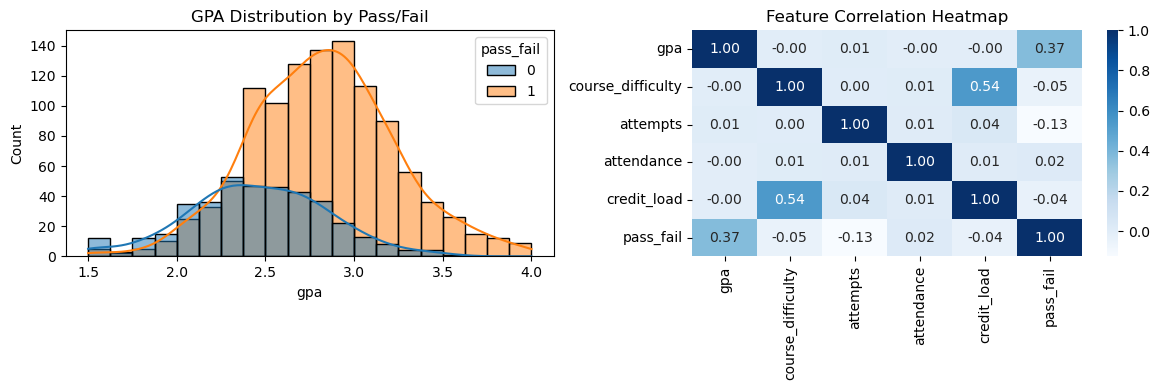

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

eda_df = pd.read_csv(DATASET_CSV)
num_cols = ["gpa", "course_difficulty", "attempts", "attendance", "credit_load", "pass_fail"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=eda_df, x="gpa", hue="pass_fail", kde=True, ax=axes[0], bins=20)
axes[0].set_title("GPA Distribution by Pass/Fail")

corr = eda_df[num_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="Blues", ax=axes[1], fmt=".2f")
axes[1].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

## Phase 5 - Export Report Assets
This phase exports notebook outputs as PNG figures used in the report's results and appendix sections.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt

out_dir = Path("screenshots/notebook")
out_dir.mkdir(parents=True, exist_ok=True)

# Save model comparison table as PNG
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.axis("off")
ax.table(
    cellText=results_df.round(4).values,
    colLabels=results_df.columns,
    loc="center",
)
ax.set_title("Model Comparison Metrics", fontsize=12, pad=12)
fig.tight_layout()
fig.savefig(out_dir / "01_model_metrics_table.png", dpi=220, bbox_inches="tight")
plt.close(fig)

# Save feature importance table as PNG
feat_show = feature_df.head(12).copy().round(6)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.axis("off")
ax.table(
    cellText=feat_show.values,
    colLabels=feat_show.columns,
    loc="center",
)
ax.set_title("Top Feature Importances", fontsize=12, pad=12)
fig.tight_layout()
fig.savefig(out_dir / "02_feature_importance_table.png", dpi=220, bbox_inches="tight")
plt.close(fig)

print("Saved:", out_dir / "01_model_metrics_table.png")
print("Saved:", out_dir / "02_feature_importance_table.png")

Saved: screenshots/notebook/01_model_metrics_table.png
Saved: screenshots/notebook/02_feature_importance_table.png


In [7]:
# Export BI EDA visuals as PNG for report embedding
from pathlib import Path

eda_out = Path("screenshots/notebook")
eda_out.mkdir(parents=True, exist_ok=True)

eda_df = pd.read_csv(DATASET_CSV)
num_cols = ["gpa", "course_difficulty", "attempts", "attendance", "credit_load", "pass_fail"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=eda_df, x="gpa", hue="pass_fail", kde=True, ax=axes[0], bins=20)
axes[0].set_title("GPA Distribution by Pass/Fail")

corr = eda_df[num_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="Blues", ax=axes[1], fmt=".2f")
axes[1].set_title("Feature Correlation Heatmap")

plt.tight_layout()
fig.savefig(eda_out / "03_bi_eda_distributions_and_correlation.png", dpi=220, bbox_inches="tight")
plt.close(fig)

program_pass = (
    eda_df.groupby("program", as_index=False)["pass_fail"]
    .mean()
    .sort_values("pass_fail", ascending=False)
)
fig, ax = plt.subplots(figsize=(7.2, 4))
sns.barplot(data=program_pass, x="program", y="pass_fail", ax=ax, palette="Blues_d")
ax.set_ylabel("Average Pass Rate")
ax.set_xlabel("Program")
ax.set_title("Program-level Pass Rate Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(eda_out / "04_bi_program_pass_rate.png", dpi=220, bbox_inches="tight")
plt.close(fig)

print("Saved:", eda_out / "03_bi_eda_distributions_and_correlation.png")
print("Saved:", eda_out / "04_bi_program_pass_rate.png")

/tmp/ipykernel_625964/808521194.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=program_pass, x="program", y="pass_fail", ax=ax, palette="Blues_d")


Saved: screenshots/notebook/03_bi_eda_distributions_and_correlation.png
Saved: screenshots/notebook/04_bi_program_pass_rate.png
